# Mental Health in Tech: Predicting Treatment-Seeking Behavior
This notebook analyses the OSMI Mental Health in Tech Survey dataset, with the aim of exploring how workplace factors and attitudes towards mental health in the workplace influences employee's help-seeking behaviors.

## 🎯 Objectives

* Clean and prepare the dataset to ensure accuracy and usability.
* Perform EDA to explore relationships between factors and mental health help-seeking behavior.
* Build and test a logistic regression model to investigate significant predictors in help-seeking behavior.

## 📊 Dataset
* Source: [OSMI Mental Health in Tech Survey] [Mental Health in Tech Survey - Kaggle](https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey/data)
* Number of Rows: 1,259
* Number of Columns: 27
* Key Columns: Age, Gender, Treatment, Family History, etc

### Load Dataset
We start by loading the OSMI Mental Health in Tech Survey dataset into a Pandas dataframe.

In [1]:
# Load dataset
import pandas as pd

!kaggle datasets download -d osmi/mental-health-in-tech-survey
!unzip -l mental-health-in-tech-survey.zip

df = pd.read_csv('survey.csv')
X = df.copy()

X.head()

Dataset URL: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey
License(s): CC-BY-SA-4.0
mental-health-in-tech-survey.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  mental-health-in-tech-survey.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   303684  09-20-2019 00:04   survey.csv
---------                     -------
   303684                     1 file


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


The dataset contains 1,259 rows and 27 columns. Each row refers to a unique survey response from an individual participant.

### Inspect the Data
We check the column names, data types, and the number of missing values to better understand ths structure of the dataset.

In [2]:
# Inspect structure of dataset
X.info()
X.isna().sum().head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

Timestamp      0
Age            0
Gender         0
Country        0
state        515
dtype: int64

## 🧹 Data Cleaning
In this section, we prepare the dataset for analysis by:
* Removing invalid age ranges for the `Age` column
* Standardizing the values in the `Gender` column
* Handling missing values
* Rename columns
* Dropping irrelevant or redundant columns
* Encoding categorical variables

###  Remove invalid values for the `age` column
Rows with age values outside the range of 18-100 are removed to ensure that data is valid for analysis.

In [3]:
# Remove values outside the valid age range
X = X[(X['Age'] >= 18) & (X['Age'] <= 100)]

### Standardize values in the `gender` column
We simplified gender into three categories: **Male**, **Female**, and **Other**. Entries that did not clearly fall under Male or Female were grouped into **Other** for clarity in EDA and modeling.

In [4]:
# Standardize the values (e.g. Male, Female, Unknown, Others)
def clean_gender(gender):
    gender = str(gender).strip().lower()

    if gender in ["male", 'm', 'cis male', 'man', 'cis man', 'male (cis)', 'maile', 'mal', 'msle', 'make', 'malr', 'mail']:
        return 'Male'
    elif gender in ['female', 'f', 'cis female', 'femake', 'woman', 'cis-female/femme', 'female(cis)', 'femail']:
        return 'Female'
    else:
        return 'Other'

X.loc[:, 'gender_cleaned'] = X['Gender'].apply(clean_gender)

### Handle missing values
We impute/drop missing values as appropriate.

In [5]:
# Fill missing values in the `self_employed` column with 'No Answer'
X.loc[:, 'self_employed'] = X['self_employed'].fillna('No Answer')

# Fill missing values in the `state` column with 'Not Applicable'
X.loc[:, 'state'] = X['state'].fillna('Not Applicable')

### Rename columns
We replaces spaces in column names with underscores for better readability and to simplify coding.

In [6]:
# Replace spaces in column names with underscores
X.columns = X.columns.str.lower().str.replace(" ", "_")

### Drop irrelevant/redundant columns  
We drop the redundant or irrelevant columns that we will not be using in analysis or modelling to clean and simplify the dataset.

In [7]:
# Drop the irrelevant or redundant column
cols_to_keep = ['age', 'treatment', 'gender_cleaned',
                'mental_health_consequence', 'coworkers', 'supervisor', 
                'mental_health_interview', 'no_employees', 'remote_work', 
                'benefits', 'care_options', 'wellness_program', 
                'seek_help', 'anonymity', 'leave']
X = X[cols_to_keep]

### Encode columns with categorical data
We encode categorical variables into numeric values so that they can be used in analysis and modelling.
* Ordinal variables are mapped to integers that represent their order
* Nominal variables are one-hot encoded

In [8]:
X_encoded = X.copy()

# --- Ordinal Encoding ---
# --- Encode Yes/No/Don't know columns ---
yes_no_cols = ['remote_work', 'benefits', 'wellness_program', 'seek_help',
                 'anonymity']
yes_no_map = {
            "Yes":1,
            "No": 0,
            "Don't know": 0.5
}
for col in yes_no_cols:
    X_encoded[col] = X_encoded[col].map(yes_no_map)

# --- Encode Leave difficulty column ---
leave_map = {
            "Very difficult":1,
            "Somewhat difficult": 2,
            "Don't know": 3,
            "Somewhat easy": 4,
            "Very easy": 5
}
X_encoded['leave'] = X_encoded['leave'].map(leave_map)

# --- Encode Treatment Yes/No columns ---
X_encoded['treatment'] = X_encoded['treatment'].map({'Yes':1, 'No':0})
X['treatment_encoded'] = X_encoded['treatment']

# --- Encode Care Options Yes/No/Not sure columns ---
X_encoded['care_options'] = X_encoded['care_options'].map({'Yes':1, 'No':0, 'Not sure': 0.5})

# --- Encode Yes/No/Maybe columns ---
attitude_cols_1 = ['mental_health_consequence', 'mental_health_interview']
yes_no_maybe_map = {
            "Yes":1,
            "No": 0,
            "Maybe": 0.5
}
for col in attitude_cols_1:
    X_encoded[col] = X_encoded[col].str.strip().str.capitalize()
    X_encoded[col] = X_encoded[col].map(yes_no_maybe_map)  

# --- Encode Yes/No/Some of them columns ---
attitude_cols_2 = ['coworkers', 'supervisor']
yes_no_some_map = {
            "Yes":1,
            "No": 0,
            "Some of them": 0.5
}
for col in attitude_cols_2:
    X_encoded[col] = X_encoded[col].str.strip().str.capitalize()
    X_encoded[col] = X_encoded[col].map(yes_no_some_map)

# --- Midpoint encoding for numeric intervals ---
num_map = {
    '1-5': 3,
    '6-25': 15.5,
    '26-100': 63,
    '100-500': 300,
    '500-1000': 750,
    'More than 1000': 1200
}
X_encoded['no_employees'] = X_encoded['no_employees'].map(num_map)


# --- Nominal Encoding ---
# --- One-hot Encoding ---
gender_dummies = pd.get_dummies(X['gender_cleaned'], prefix = 'gender', drop_first = True)
X_encoded = pd.concat([X_encoded, gender_dummies], axis = 1)

##  📈 Exploratory Data Analysis (EDA)
We conduct both univariate and bivariate analysis of the dataset to identify key patterns and predictors as well as to prepare insights for future modelling.

### Univariate Analysis for Numerical Features
We examine the summary statistics and distribution plot for the numerical featres in the dataset.

#### Age

##### Summary Statistics
We examine the distribution, mean, median, quartiles and potential outliers for the numerical feature in the dataset.

In [9]:
X['age'].describe()

count    1251.000000
mean       32.076739
std         7.288272
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: age, dtype: float64

The minimum and 25th percentile values, as well as the maximum and 75th percentile values, are quite far apart. This could indicate the presence of extreme outliers. Therefore, we examin the distribution plot for `age` to better undertand its spread and potential anomalies.

##### Distribution Plot
We examine the distribution for the `age` column.

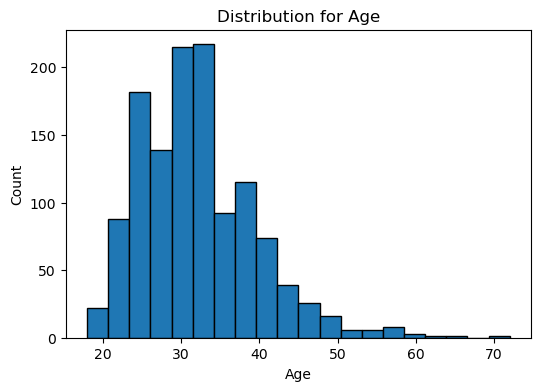

In [10]:
import matplotlib.pyplot as plt

# Plot the histogram for distribution for age
plt.figure(figsize = (6,4))
plt.hist(X['age'], bins = 20, edgecolor = 'black')

plt.title("Distribution for Age")
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

The majority of respondents are between 20 and 40 years old, with only a small proportion above 50. Given the small number of older respondents, we group ages into broader categories and analyze treatment proportions to ensure fair comparisons.

### Feature Engineering
To facilitate analysis and potential modeling, we derived a categorical variable `age_groups`, with 6 different age categories, from the continuous `age` variable. Grouping ages helps reduce the effect of small sample sizes in the older ranges and makes it easier to observe trends across age groups.

In [11]:
# Group ages into groups
def group_age(X):
    new_col = []
    
    for age in X['age']:
        if 18 <= age <= 24:
            new_col.append('18-24')
        elif 25 <= age <= 34:
            new_col.append('25-34')
        elif 35 <= age <= 44:
            new_col.append('35-44')
        elif 45 <= age <= 54:
            new_col.append('45-54')
        elif 55 <= age <= 64:
            new_col.append('55-64')
        else:
            new_col.append('65+')

    return new_col

X_encoded['age_groups'] = group_age(X)

# Convert the new categorical variable into a ordered categorical
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
X_encoded['age_groups'] = pd.Categorical(
                                        X_encoded['age_groups'],
                                        categories = age_order,
                                        ordered = True)
X['age_groups'] = X_encoded['age_groups']

### Univariate Analysis for Categorical Features
We examine the value counts and distribution plot for the categorical features in the dataset.

#### Value Counts for Categorical Features
We examine the value counts for the categorical features in the dataset to identify high or low revalence.

In [12]:
categorical_columns = ['age_groups', 'gender_cleaned',
                'mental_health_consequence', 'coworkers', 'supervisor', 
                'mental_health_interview', 'no_employees', 'remote_work', 
                'benefits', 'care_options', 'wellness_program', 
                'seek_help', 'anonymity', 'leave']

for col in categorical_columns:
    col_counts = X[col].value_counts()
    print(f'---{col}---')
    print(f'{col_counts}\n')

---age_groups---
age_groups
25-34    707
35-44    320
18-24    156
45-54     51
55-64     15
65+        2
Name: count, dtype: int64

---gender_cleaned---
gender_cleaned
Male      985
Female    246
Other      20
Name: count, dtype: int64

---mental_health_consequence---
mental_health_consequence
No       487
Maybe    476
Yes      288
Name: count, dtype: int64

---coworkers---
coworkers
Some of them    771
No              258
Yes             222
Name: count, dtype: int64

---supervisor---
supervisor
Yes             512
No              390
Some of them    349
Name: count, dtype: int64

---mental_health_interview---
mental_health_interview
No       1003
Maybe     207
Yes        41
Name: count, dtype: int64

---no_employees---
no_employees
6-25              289
26-100            288
More than 1000    281
100-500           175
1-5               158
500-1000           60
Name: count, dtype: int64

---remote_work---
remote_work
No     880
Yes    371
Name: count, dtype: int64

---benefits---
be

Based on the value counts, we further examine the age groups, gender, coworkers, supervisor, benefits, and care options columns through their value counts and distribution plots.

#### Age Groups
We examine the value counts and distribution plot for the `age_groups` column.

##### Value Count

In [13]:
age_count = X['age_groups'].value_counts()
print(f'The value count for: {age_count}')

The value count for: age_groups
25-34    707
35-44    320
18-24    156
45-54     51
55-64     15
65+        2
Name: count, dtype: int64


##### Distribution Plot

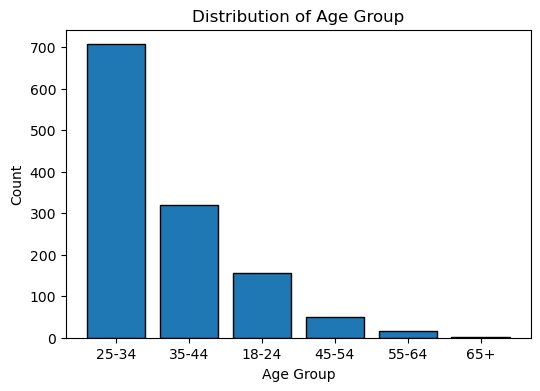

In [14]:
# Plot the barchart for distribution of age group
plt.figure(figsize = (6,4))
plt.bar(age_count.index, age_count, edgecolor = 'black')

plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Distribution of Age Group')

plt.show()

The number of respondents decreases with age, with the majority being between 25 to 34 years old, and only a very small minorty aged 55 and above.

#### Gender
We examine the value counts and distribution plot for the `gender_cleaned` column.

##### Value Count

In [15]:
gender_count = X['gender_cleaned'].value_counts()
print(f'The value count for: {gender_count}')

The value count for: gender_cleaned
Male      985
Female    246
Other      20
Name: count, dtype: int64


##### Distribution Plot

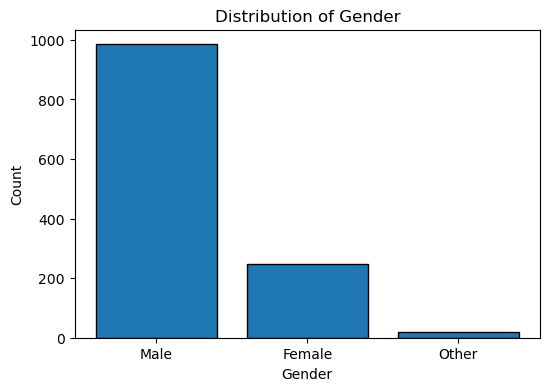

In [16]:
# Plot the barchart for distribution of gender
plt.figure(figsize = (6,4))
plt.bar(gender_count.index, gender_count, edgecolor = 'black')

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')

plt.show()

The majority of respondents identified as male, followed by a smaller proportion of females. A minority identified as other genders or did not specify.

#### Openness to MH Discussion with Coworkers
We examine the value count and distribution plot for the `coworkers` column.

##### Value Count

In [17]:
coworkers_count = X['coworkers'].value_counts()
print(f'The value count for: {coworkers_count}')

The value count for: coworkers
Some of them    771
No              258
Yes             222
Name: count, dtype: int64


##### Distribution Plot

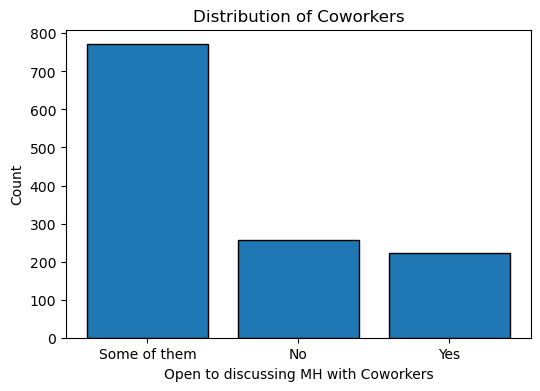

In [18]:
# Plot the barchart for distribution of coworkers
plt.figure(figsize = (6,4))
plt.bar(coworkers_count.index, coworkers_count, edgecolor = 'black')

plt.xlabel('Open to discussing MH with Coworkers')
plt.ylabel('Count')
plt.title('Distribution of Coworkers')

plt.show()

Most respondents were open to discussing mental health with some coworkers, while smaller and relatively similar proportions were either open to all or not open at all.

#### Openness to MH Discussion with Supervisor
We examine the value count and distribution plot for the `supervisor` column.

##### Value Count

In [19]:
supervisor_count = X['supervisor'].value_counts()
print(f'The value count for: {supervisor_count}')

The value count for: supervisor
Yes             512
No              390
Some of them    349
Name: count, dtype: int64


##### Distribution Plot

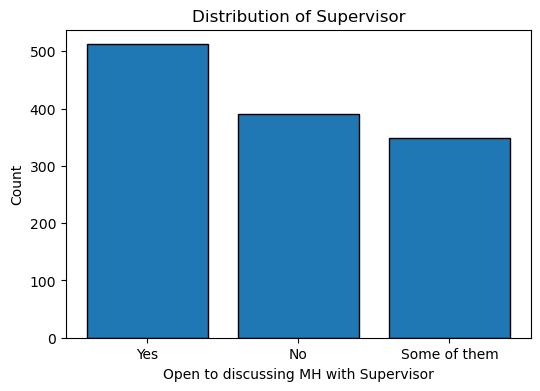

In [20]:
# Plot the barchart for distribution of supervisor
plt.figure(figsize = (6,4))
plt.bar(supervisor_count.index, supervisor_count, edgecolor = 'black')

plt.xlabel('Open to discussing MH with Supervisor')
plt.ylabel('Count')
plt.title('Distribution of Supervisor')

plt.show()

Most respondents were open to discussing mental health with their supervisor, while smaller proportions were either not open or only open to some. Slightly more respondents were not open compared to those open to some.

#### Company MH Benefits
We examine the value count and distribution plot for the `benefits` column.

##### Value Count

In [21]:
benefits_count = X['benefits'].value_counts()
print(f'The value count for: {benefits_count}')

The value count for: benefits
Yes           473
Don't know    407
No            371
Name: count, dtype: int64


##### Distribution Plot

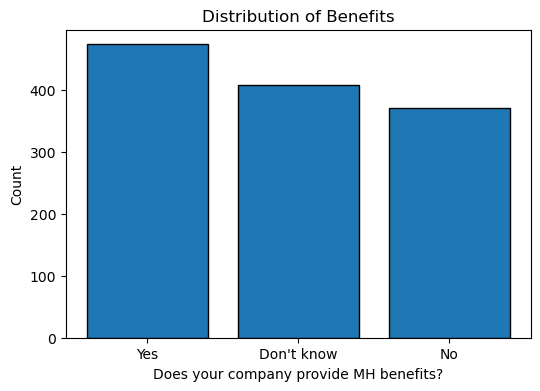

In [22]:
# Plot the barchart for distribution of benefits
plt.figure(figsize = (6,4))
plt.bar(benefits_count.index, benefits_count, edgecolor = 'black')

plt.xlabel('Does your company provide MH benefits?')
plt.ylabel('Count')
plt.title('Distribution of Benefits')

plt.show()

Respondents were relatively evenly split, with most reporting that their company provides mental health benefits, followed by those who were unsure, and finally those whose companies did not provide benefits.

#### Awareness of Company MH Care Options
We examine the value counts and distribution plot for the `care_options` column.

##### Value Count

In [23]:
care_count = X['care_options'].value_counts()
print(f'The value count for: {care_count}')

The value count for: care_options
No          499
Yes         439
Not sure    313
Name: count, dtype: int64


##### Distribution Plot

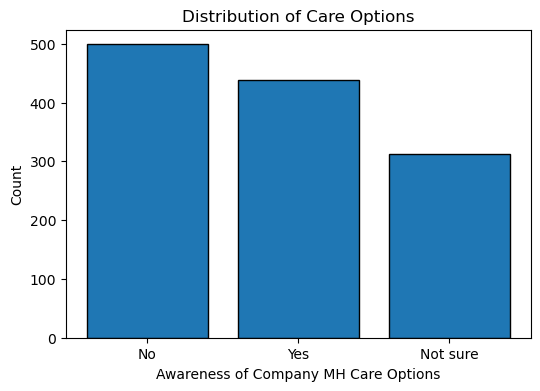

In [24]:
# Plot the barchart for distribution of Care Options
plt.figure(figsize = (6,4))
plt.bar(care_count.index, care_count, edgecolor = 'black')

plt.xlabel('Awareness of Company MH Care Options')
plt.ylabel('Count')
plt.title('Distribution of Care Options')

plt.show()

Respondents were relatively evenly split, with most being unware of their company mental health care options, followed by those who were aware, and finally those who were unsure.

### Target Variable Check
We examine the value counts and distribution plot of the target feature, treatment.

#### Value Count

In [25]:
treatment_count = X['treatment'].value_counts()
print(f'The value count for: {treatment_count}')

The value count for: treatment
Yes    632
No     619
Name: count, dtype: int64


#### Distribution Plot

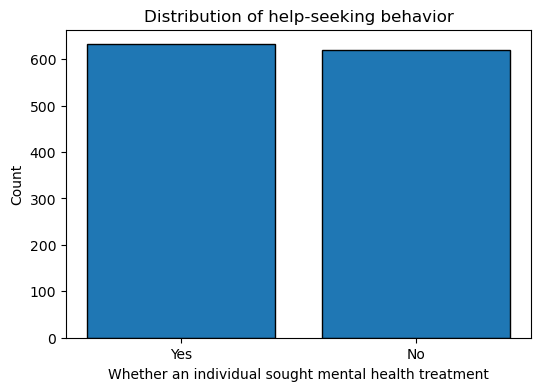

In [26]:
# Plot the histogram for distribution of help-seeking behavior
plt.figure(figsize = (6,4))
plt.bar(treatment_count.index, treatment_count, edgecolor = 'black')

plt.title('Distribution of help-seeking behavior')
plt.xlabel('Whether an individual sought mental health treatment')
plt.ylabel('Count')

plt.show()

The distribution of help-seeking behavior was fairly balanced, with a slightly higher proportion of respondents reporting that they have sought mental health treatment before.

### Association/Correlation Check
We examine the association/correlation between the categorical and numerical features and the target (treatment) respectively to idenitfy potential predictors and multicollinearity.

#### Association Check for Categorical Features
We examine the association between categorical features and target to identify those with potential predictive signals.

##### Chi-Square Test of Independence for Gender

In [27]:
from scipy.stats import chi2_contingency

gender_table = pd.crosstab(X['treatment'], X['gender_cleaned'])

gender_stat, gender_p, gender_df, gender_ef = chi2_contingency(gender_table)

print('Gender:')
print(f'Chi-Square Statistic: {gender_stat}')
print(f'P-value: {gender_p}')
print(f'Degrees of Freedom: {gender_df}')
print(f'Expected Frequencies: {gender_ef}\n')

alpha = 0.05
if gender_p < alpha:
    print('Reject the null hypothesis: There is a significant association between Gender and Treatment.')
else:
    print('Fail to reject the null hypothesis: There is a no significant association between Gender and Treatment.')

Gender:
Chi-Square Statistic: 49.19602639827101
P-value: 2.0759581866574545e-11
Degrees of Freedom: 2
Expected Frequencies: [[121.72182254 487.38209432   9.89608313]
 [124.27817746 497.61790568  10.10391687]]

Reject the null hypothesis: There is a significant association between Gender and Treatment.


The Chi-square test of independence shows p < 0.05, so we reject the null hypothesis and conclude there is a significant association between gender and treatment.

##### Chi-Square Test of Independence for Age Groups

In [28]:
age_table = pd.crosstab(X['treatment'], X['age_groups'])

age_stat, age_p, age_df, age_ef = chi2_contingency(age_table)

print('Age Groups:')
print(f'Chi-Square Statistic: {age_stat}')
print(f'P-value: {age_p}')
print(f'Degrees of Freedom: {age_df}')
print(f'Expected Frequencies: {age_ef}\n')

alpha = 0.05
if age_p < alpha:
    print('Reject the null hypothesis: There is a significant association between Age Groups and Treatment.')
else:
    print('Fail to reject the null hypothesis: There is a no significant association between Age Groups and Treatment.')

Age Groups:
Chi-Square Statistic: 8.865088120897772
P-value: 0.11456785578649412
Degrees of Freedom: 5
Expected Frequencies: [[ 77.18944844 349.82653877 158.33733014  25.23501199   7.42206235
    0.98960831]
 [ 78.81055156 357.17346123 161.66266986  25.76498801   7.57793765
    1.01039169]]

Fail to reject the null hypothesis: There is a no significant association between Age Groups and Treatment.


The Chi-square test of independence shows p > 0.05, so we fail to reject the null hypothesis and conclude there is no significant association between age groups and treatment.

#### Correlation Matrix for Numerical and Ordinal Features
We examine the correlation matrix for the numerical/ordinal features and the target (treatment) to identify potential predictors and multicollinearity.

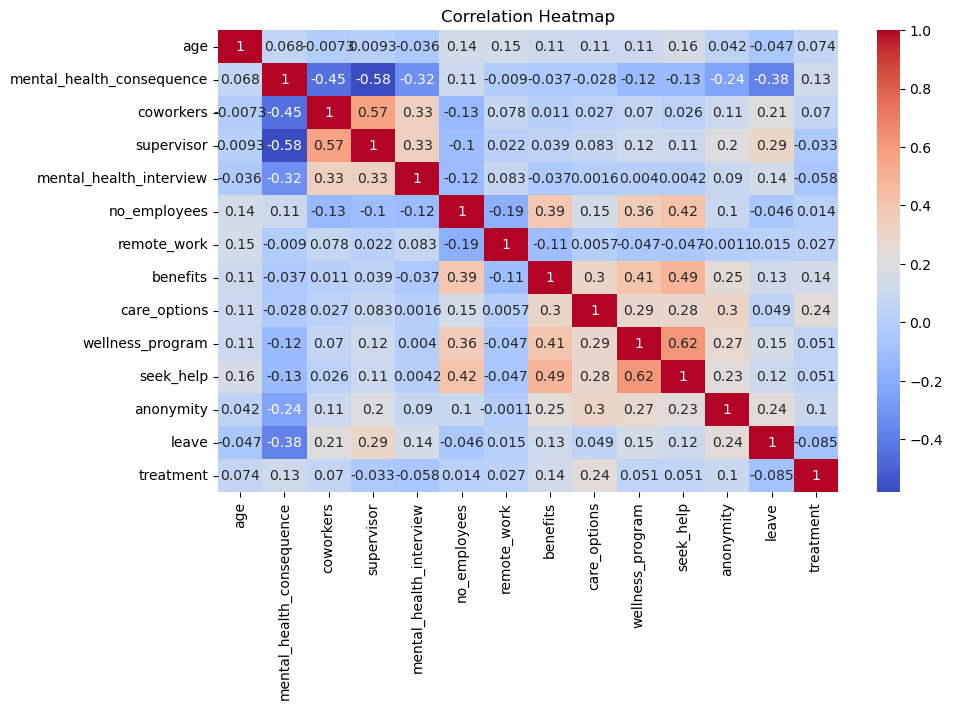

In [29]:
import seaborn as sns

ordinal_features = ['age', 'mental_health_consequence', 'coworkers', 'supervisor', 
                'mental_health_interview', 'no_employees', 'remote_work', 
                'benefits', 'care_options', 'wellness_program', 
                'seek_help', 'anonymity', 'leave', 'treatment']

# Plot the correlation heatmap for the numerical and ordinal features
plt.figure(figsize = (10,6))
sns.heatmap(X_encoded[ordinal_features].corr(),annot = True, cmap = 'coolwarm')

plt.title('Correlation Heatmap')

plt.show()

The correlation heatmap shows that some predictors are moderately (|corr| > 0.2) or strongly correlated (|corr| > 0.5) with each other. For bivariate analysis, we focus on features correlated with the target (|corr| > 0.1), while noting relationships among correlated predictors.

### Bivariate Analysis
We conduct bivariate analysis on features that are correlated with the target and/or deemed conceptually relevant based on univariate trends.

####  Treatment by Age
Although the correlation between age and treatment is low, we include age in our analysis because previous studies suggest age may influence help-seeking behavior.

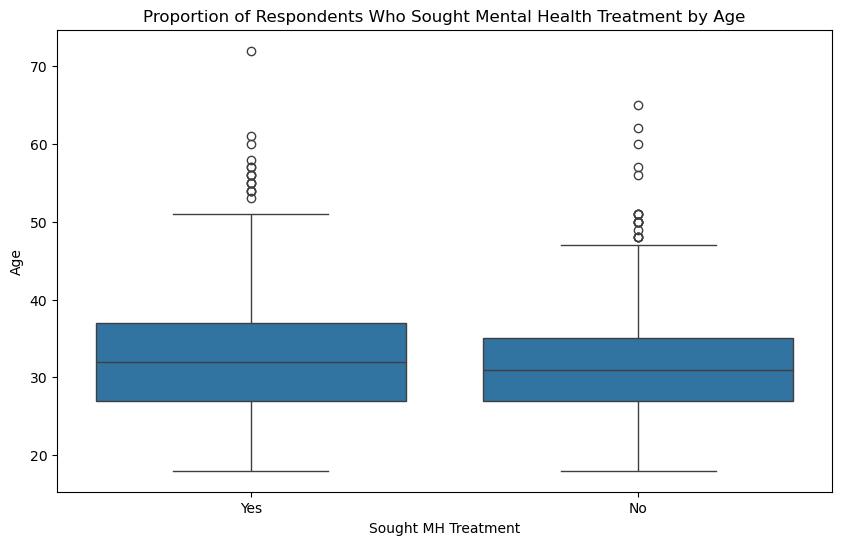

In [30]:
import seaborn as sns

# Bar chart showing treatment by age
plt.figure(figsize = (10,6))
plt.title("Proportion of Respondents Who Sought Mental Health Treatment by Age")

sns.boxplot(y = 'age', x = 'treatment', data = X)

plt.ylabel('Age')
plt.xlabel('Sought MH Treatment')

plt.show()

Respondents who sought treatment tend to be slightly older on average, with a median around 32 compared to 31 for those who did not. Both groups have a wide range of ages and a few older respondents appear as outliers.

####  Treatment by Gender
We examine the proportion of respondents in each gender category who has sought mental health treatment.

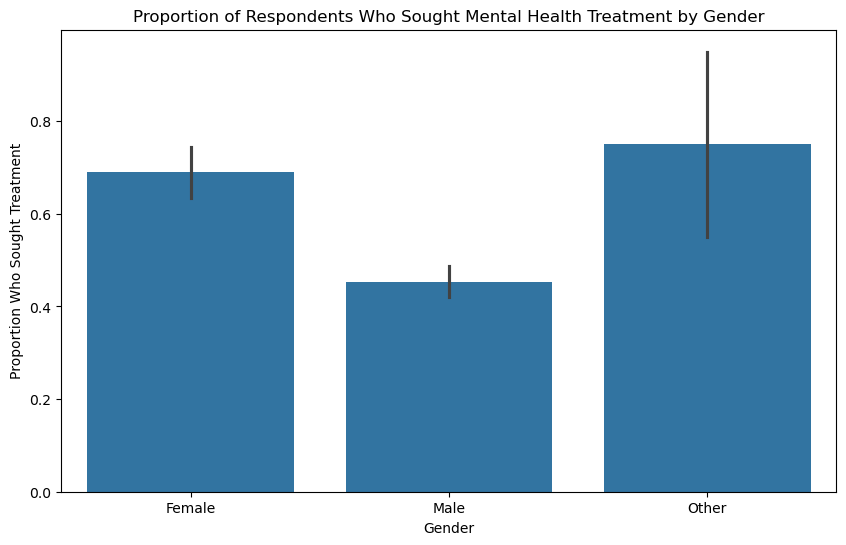

In [31]:
# Bar chart showing treatment by gender
plt.figure(figsize = (10,6))
plt.title("Proportion of Respondents Who Sought Mental Health Treatment by Gender")

sns.barplot(x = 'gender_cleaned', y = 'treatment', data = X_encoded, estimator = lambda x: sum(x)/len(x))

plt.ylabel('Proportion Who Sought Treatment')
plt.xlabel('Gender')

plt.show()

Help-seeking behavior varied by gender, with females and other-gender respondents showing higher proportions of treatment compared to males. This suggests gender may play a role in attitudes toward seeking support.

#### Treatment Proportion by Company MH Benefits
We examine the proportion of respondents who sought mental health treatment by whether their company provides mental health benefits.

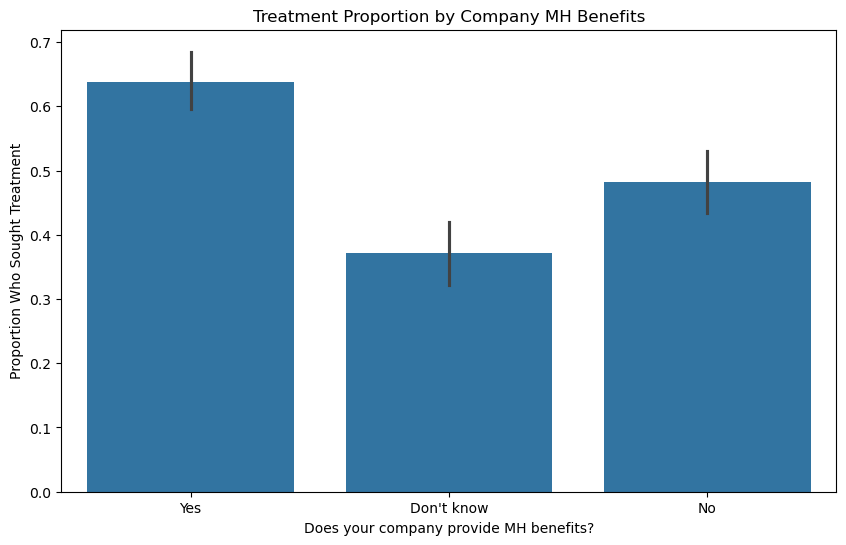

In [32]:
# Bar chart for benefits against treatment
plt.figure(figsize = (10,6))
plt.title("Treatment Proportion by Company MH Benefits")

sns.barplot(x = 'benefits', y = 'treatment_encoded', data = X, estimator = lambda x: sum(x)/len(x))

plt.ylabel('Proportion Who Sought Treatment')
plt.xlabel('Does your company provide MH benefits?')

plt.show()

Help-seeking behavior varied by whether a company provided mental health benefits. Respondents who knew their company offered benefits had the highest proportion of treatment-seeking, followed by those who knew benefits were not provided, while those unaware showed the lowest proportion.

#### Treatment Proportion by Perceived Negative Consequences to Discussing MH with Employer
We examine the proportion of respondents who sought mental health treatment by their perceived consequences to discussing mental health with an employer.

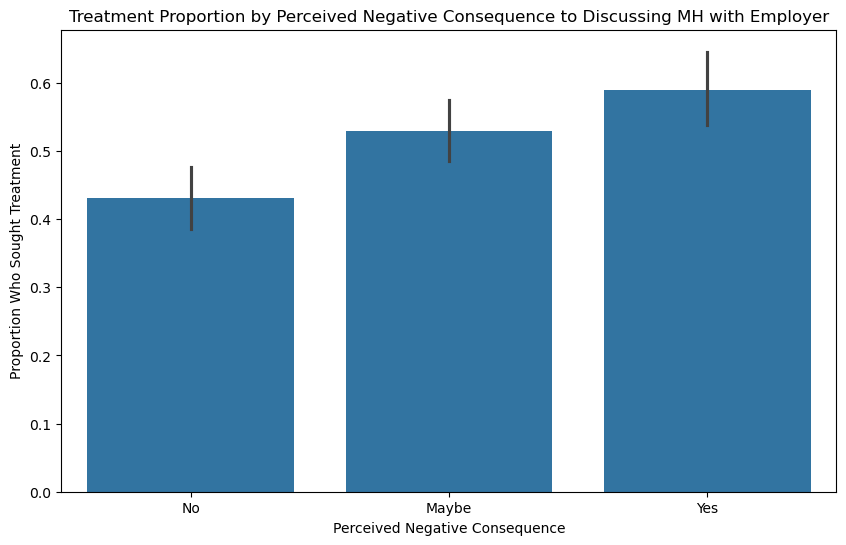

In [33]:
# Bar chart for mental health consequence against treatment
plt.figure(figsize = (10,6))
plt.title("Treatment Proportion by Perceived Negative Consequence to Discussing MH with Employer")

sns.barplot(x = 'mental_health_consequence', y = 'treatment_encoded', data = X, estimator = lambda x: sum(x)/len(x))

plt.ylabel('Proportion Who Sought Treatment')
plt.xlabel('Perceived Negative Consequence')

plt.show()

Help-seeking behavior varied by perceived consequences of discussing mental health with an employer. A higher proportion of respondents who sought mental health treatment perceived negative consequences compared to those who perceived no or uncertain consequences. 

#### Treatment Proportion by Awareness of Company MH Care Options
We examine the proportion of respondents who sought mental health treatment by their awareness of their company's mental health care options.

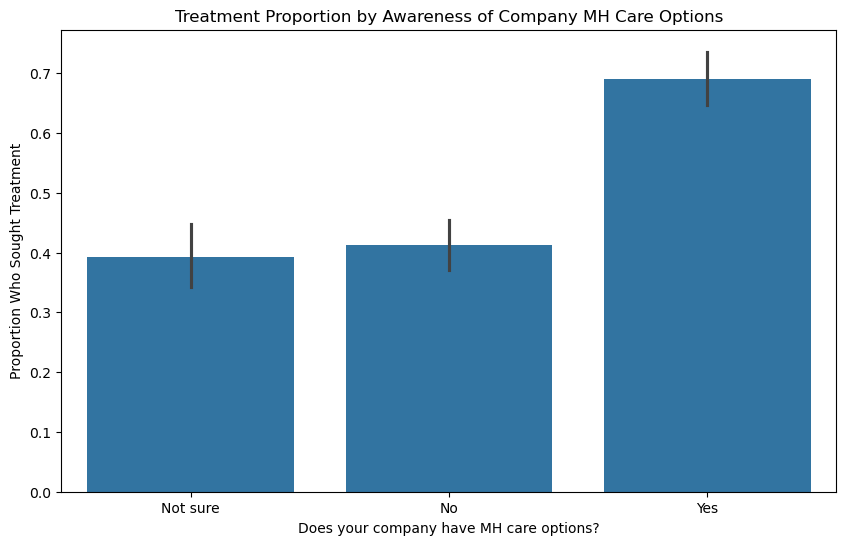

In [34]:
# Bar chart for care options against treatment
plt.figure(figsize = (10,6))
plt.title("Treatment Proportion by Awareness of Company MH Care Options")

sns.barplot(x = 'care_options', y = 'treatment_encoded', data = X, estimator = lambda x: sum(x)/len(x))

plt.ylabel('Proportion Who Sought Treatment')
plt.xlabel('Does your company have MH care options?')

plt.show()

Help-seeking behavior varied by whether a company had mental health care options. Respondents who knew their company offered care options had the highest proportion of treatment-seeking, followed by those who knew that there were no care options, while those unaware showed the lowest proportion.


#### Treatment Proportion by Anonymity
We examine the proportion of respondents who sought mental health treatment by whether their anonymity would be protected if they made use of their company's mental health resources.

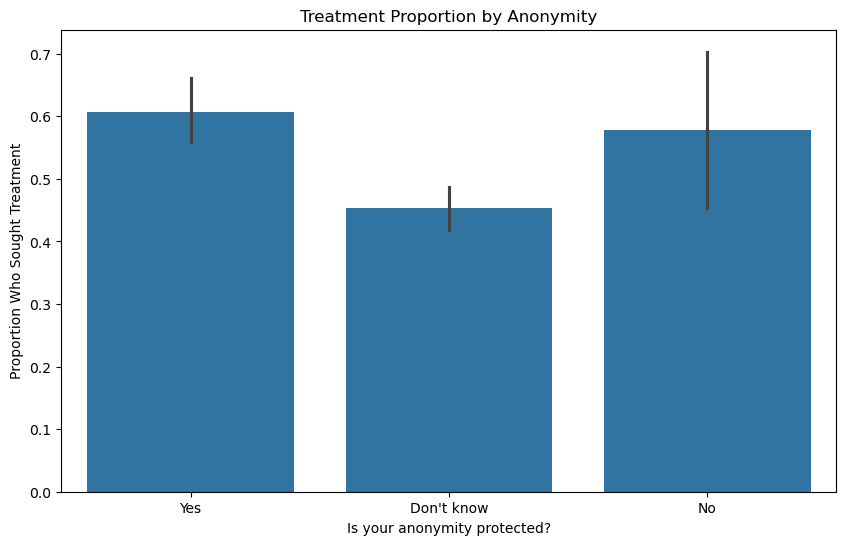

In [35]:
# Bar chart for anonymity against treatment
plt.figure(figsize = (10,6))
plt.title("Treatment Proportion by Anonymity")

sns.barplot(x = 'anonymity', y = 'treatment_encoded', data = X, estimator = lambda x: sum(x)/len(x))

plt.ylabel('Proportion Who Sought Treatment')
plt.xlabel('Is your anonymity protected?')

plt.show()

Help-seeking behavior varied depending on whether anonymity was protected when using company mental health resources. Respondents who knew that their anonymity would be protected (or not protected) reported relatively high and similar rates of treatment-seeking, while those who were unsure showed the lowest proportion.

### EDA Key Summary
The exploratory data analysis provided an overview of the dataset's structure, distributions, and relationships across key variables. Overall, help-seeking behavior was associated with both demographic (age, gender) and workplace factors (benefits, care options, perceived mental health consequences). Age showed a gradual increase in treatment-seeking up to the 65+ group, while respondents identifying as women or other genders reported higher treatment-seeking compared to men. Workplace support factors were also generally linked to higher treatment rates. Finally, several predictors showed moderate multicollinearity, which we will account for during feature selection before modeling.

## 🛠️ Feature Selection
From the EDA, we selected predictors that showed a moderate correlation with the target (treatment, |corr| > 0.1), along with age and gender, which have previously been studied to be associated with mental health treatment-seeking behavior. Predictors that were either highly collinear with one another and/or showed little to no correlation with the target were excluded. We now compute VIF on the selected features to confirm that no problematic multicollinearity remains before modeling.

### Variance Inflation Factors (VIF)
We compute the VIF for the selected features to ensure and confirm that there is no problematic multicollinearity that remains between these features.

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

selected_features = ['gender_Male', 'gender_Other', 'age', 'benefits', 'mental_health_consequence', 'care_options', 'anonymity', 'treatment']

selected_X = X_encoded[selected_features].copy()
selected_X['gender_Male'] = selected_X['gender_Male'].astype(int)
selected_X['gender_Other'] = selected_X['gender_Other'].astype(int)

vif_data = pd.DataFrame()
vif_data['Features'] = selected_X.columns
vif_data['VIF'] = [variance_inflation_factor(selected_X.values, i) for i in range(len(selected_X.columns))]

print(vif_data)

                    Features        VIF
0                gender_Male   4.738138
1               gender_Other   1.076425
2                        age  11.114295
3                   benefits   3.169725
4  mental_health_consequence   2.259756
5               care_options   2.723876
6                  anonymity   6.586805
7                  treatment   2.235807


**Note:** Only age had a VIF above 10, indicating high correlation with other predictors. We retain age, as it is a meaningful variable, and do not drop any of the selected features.

Overall, based on the EDA and VIF results, we selected the following features for modeling:

* Treatment (target)
* Age
* Gender
* mental_health_consequence
* benefits
* care_options
* anonymity

## ⚙️ Modelling
In this section, we apply **Logistic Regression** to examine age, gender and/or some workplace factors could predict whether respondents sought mental health treatment.  
We approach modeling in two parts:  
1. **Inference (Statsmodels):** Identify significant predictors and interpret coefficients.  
2. **Prediction (Sklearn):** Evaluate predictive performance with accuracy metrics.

### Modelling Setup
We prepare the data for modelling by focusing on the selected features and splitting the data into train and test data.

In [37]:
model_features = ['age', 'gender_Male', 'gender_Other', 'mental_health_consequence', 'benefits', 'care_options', 'anonymity']
x = X_encoded[model_features].copy()
y = X_encoded['treatment']

### Logistic Regression with Statsmodels (Inference)
We use Statsmodels to assess which features significantly predict mental health treatment-seeking behavior. This allows us to obtain coefficients, p-values, and odds ratios.

In [38]:
# Fit statslearn logistic regression
import statsmodels.api as sm

x['gender_Male'] = x['gender_Male'].astype(int)
x['gender_Other'] = x['gender_Other'].astype(int)

X_sm = sm.add_constant(x)
model_sm = sm.Logit(y, X_sm).fit()

# Summary Table (includes coefficients and p-values)
print(f'\nSummary Table:\n{model_sm.summary()}\n')

# Odds ratio
import numpy as np

odds_ratio = np.exp(model_sm.params)

colum_name = ['Odds Ratio']
odds_df = pd.DataFrame(odds_ratio, columns = colum_name)
odds_df['Rounded'] = odds_df['Odds Ratio'].round(2)
print(f'Odds Ratio:\n{odds_df}')

Optimization terminated successfully.
         Current function value: 0.637569
         Iterations 5

Summary Table:
                           Logit Regression Results                           
Dep. Variable:              treatment   No. Observations:                 1251
Model:                          Logit   Df Residuals:                     1243
Method:                           MLE   Df Model:                            7
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                 0.08011
Time:                        23:32:51   Log-Likelihood:                -797.60
converged:                       True   LL-Null:                       -867.06
Covariance Type:            nonrobust   LLR p-value:                 8.553e-27
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -0.9789      0.333     -2.935    

**Interpretation**:
* Respondents who were male have a 42% lower odds of seeking mental health treatment compared to females (*p* < 0.001).
* Responedents who have a perceived negative consequence to disgussing mental health with employers had 2.07 times higher odds of seeking treatment (*p* < 0.001).
* Respondents whose company provided mental health care options had 2.46 times higher odds of seeking treatment (*p* < 0.001).
* Respondents who felt their anonymity was protected when accessing company mental health resources had 1.63 times higher odds of seeking treatment (*p* = 0.047).

Overall, gender and workplace factors, specifically perceived consequences, availability of mental health care options, and anonymity, were significant predictors of treatment-seeking behavior.

### Logistic Regression with Sklearn (Prediction)
We now use Sklearn to evaluate the model's **predictive performance** on test, unseen data. We assess accuracy, precision, recall, F1-score, and ROC-AUC.

Confusion Matrix:
[[90 34]
 [44 83]]

Cassification Report:
                           precision    recall  f1-score   support

Did not seek MH treatment       0.67      0.73      0.70       124
      Sought MH treatment       0.71      0.65      0.68       127

                 accuracy                           0.69       251
                macro avg       0.69      0.69      0.69       251
             weighted avg       0.69      0.69      0.69       251


ROC_AUC:
0.7259017018034035

ROC Curve:


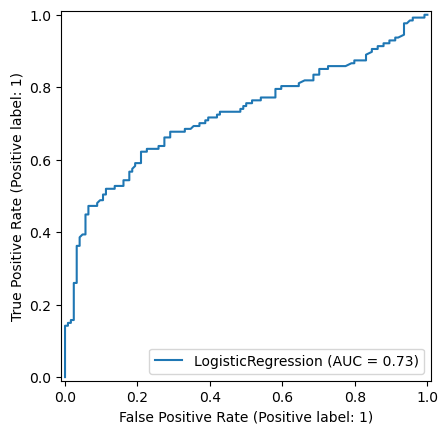

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split

# Split data into train and test data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 0)

# Fit sklearn logistic regression
model = LogisticRegression(penalty = None, random_state = 0)
model.fit(x_train, y_train)

# Predictions
test_pred = model.predict(x_test)
y_pred = model.predict_proba(x_test)[:, 1]

# Evaluation:
print(f'Confusion Matrix:\n{confusion_matrix(y_test, test_pred)}\n')
target_names = ['Did not seek MH treatment', 'Sought MH treatment']
print(f'Cassification Report:\n{classification_report(y_test, test_pred, target_names = target_names)}\n')
print(f'ROC_AUC:\n{roc_auc_score(y_test, y_pred)}\n')

# ROC Curve
print('ROC Curve:')
RocCurveDisplay.from_estimator(model, x_test, y_test)

**Interpretation**:

* Accuracy (69%): The model correctly classified 69% of the cases overall.
* Precision (71%): When the model predicted that a person will seek mental health treatment, it was correct 71% of the time.
* Recall (65%): Among respondents who actually sought mental health treatment, the model could identify 65% of them.
* ROC AUC Score (0.73): The model has moderate ability to distinguish between individuals who sought treatment and those who did not.

Overall, this model achieved an accuracy of 69% and an AUC score of 0.73, indicating moderate predictive ability.

## 🔍 Key Insights

### Model Performance:
* The logistic regression model achieved an accuracy of 69% and an AUC score of 0.73, indicating moderate predictive ability for mental health treatment-seeking behavior.

### Feature Performance:
* Among the predictors, only gender and workplace factors, specifically perceived consequences, availability of mental health care options, and protected anonymity, were found to be significant in predicting treatment-seeking behavior.

## 💡 Next Steps
**Deepen the analysis:**
* Investigate potential interaction effects to uncover how a combinations of factors (e.g., benefits and anonymity) may impact behavior.
* Fit a more complex ML model for mental health treatment-seeking predictive ability.

**Enhance the model through feature engineering:**
* Refine the current model through feature engineering or transforming current features.
* Focus on the features that have shown statistical significance and investigate the potential interaction effects between features.

## ✅ Conclusion
* Dataset was cleaned and explored using EDA.
* Identified key features related to mental health treatment-seeking behavior
* Built a simple logistic regression model that showed moderate predictive ability.